# Overjammed shape anneal with global flatness trading, 32 → 4

The packing is held **overjammed the whole way** — every polygon squeezed, every contact loaded — and
the shape freedom is what absorbs the overlap. A **global distribution constraint** lets polygons
*trade* that deformation: two rows for the entire packing on the mean and variance of `d/(a+b)` over
the vertices a stage is about to remove. One polygon may stay bent while another goes flat. The vertex
count then withdraws the freedom, 32 → 16 → 8 → 4, and only at the very end is the packing released.

Neither earlier cascade was a search. Both deformed a packing continuously inside whatever basin it
started in, and both underperformed: alternating-pairs *lost* ground (side 2.7003 → 2.9449), morph
finished 0.63% off the proved 2.70710678 with the whole apparatus worth 0.120% over a rigid control.
The recorded diagnosis (`project_optimum_is_a_minimum`) is that the known optimum **is** a minimum of
our energy, so the shortfall is a **search** failure. Loading the packing is the attempt to make it
rearrange rather than merely deform.

---

## What the gate measured before this notebook was written

**1. Every previous run was being CRUSHED, not pressed.** `holdExcessEnergy`'s own docstring measures
the band: `1e-09` is the noise floor with no density trend at all; `1e-06` ≈ 3% areal overlap, "the
intended just above jamming"; `2.4e-05` ≈ 13% overlap, "not a packing being pressed together but one
being crushed". **Every notebook in this repo used `excess = 5e-5`** — twice the crush ceiling,
inherited from `annealNgonMorph`. This one holds **5e-6**.

**2. The moment family had never been run.** `tests/flattenCascadeCheck.ramp` is documented as walking
the diagonal MOMENTS and handing off, and quotes measurements for it — but its body goes straight to
the per-object `flatten` family and prints its one result twice, labelled "(moments)" and
"(per vertex)". `setConstraints(diagonal = [1, 2])` was never called as a live constraint anywhere.
It is now checked in `tests/flatnessMomentCheck.py`: the Jacobian matches central differences to
**1.36e-10**, and it really is **2 rows for the whole packing** covering every selected vertex.

**3. The plateau is real, so the handoff is not optional.** Moments alone left the worst selected
vertex at **0.999899** and could not finish; per-object `flatten` rows took it to **0.99999900**, after
which `halveNumEdges` accepted.

**4. `equilateral = kappa` cannot be used here — it opens a kappa gap.** `setShapeTemplate`'s morph
*sets* kappa (3.586 at morph 0.3), while `equilateral = 4.0` demands 4. Crossing that in one
projection folds the polygons: measured `|turn|` **360.000 → 626.477**. So this protocol keeps the
template's **per-object edges and area** and swaps only the *diagonals* for moments. No gap.

**5. A square-doubled seed gives the ramp nothing to grip.** Its non-corner vertices are *exactly*
collinear, so `d/(a+b) = 1.000000` with spread `1.5e-13` on the whole selected set — and the corners
always land on the phase that survives every halving, so this is true at every rung. Worse, no affine
operation fixes it (`spreadShapes` is a unit-determinant stretch, and affine maps preserve
collinearity). Under load the polygon then deforms at the *unselected* vertices instead: measured
`|turn|` 360 → 442.9 with flatness spread still only `2e-06`.

**6. And the seed needs PER-POLYGON morph, or there is nothing to share.** A scalar morph makes every
polygon the same shape, so the flatness distribution is a point mass — measured `spread 0.000000` with
conditioning `1.57e-16` even after the packing was loaded, because rigid shapes cannot develop
heterogeneity under load. `setShapeTemplate` takes one value per polygon exactly for this: it makes a
spread in shape an annealing freedom, and closing it means driving every entry to 1.

**So the seed comes from the REGULAR side.** `setShapeTemplate(morph = m0)` with a small `m0` gives a
polygon whose vertices are all genuinely bent — a regular 32-gon has `d/(a+b) = cos(pi/32) = 0.99518`
at every vertex — and it is simple by construction, because edge + diagonal pin the shape. The morph
walk itself is clean: measured `|turn|` exactly 360.000 and `max|C| ~1e-15` at every sub-step, at both
n = 16 and n = 32.

## The open question this notebook exists to answer

**Where does the heterogeneity come from?** Two moment rows can only share work if the distribution
they hold has real width. In free space every polygon is identical by symmetry and the distribution is
a point mass — spread `0.000000`, conditioning `2.85e-08` from the first round, the two rows already
parallel. The hypothesis here is that **the load supplies it**: neighbours squeeze different polygons
differently, so their flatness distributions genuinely differ. First measurement says it does — the
load opened the flatness spread to **0.070126** where the symmetric seed had `1.5e-13`.

That is also why the width here is **scheduled and never captured**. A moment family can only ever be
NARROWED (the variance is at a minimum on a monodisperse configuration, so the retraction has no
direction to widen along), so capturing a seed's zero width asks for a point mass and the rows then
fight the spread the load develops: measured, asked `0.000000` against a realized `0.070126`, moment
residual stuck at `8.2e-02` after 358 passes. `setFlatnessTarget` now refuses a width at that floor.

Watch `spread` and `perPoly` in the ramp log. If they collapse, the global sharing is decorative and
the protocol is the per-object ramp with extra steps.

In [1]:
import time

import numpy as np
from matplotlib import pyplot as plt

import pyPolygon as pp
import records

## 1. Seed: squares → doubled to 32 → walked round by the template

Building at n = 32 directly returns **self-intersecting** polygons (measured `|turn|` 1089 deg against
360 for a simple one) — the springs hold edge lengths and the *signed* shoelace area, and a folded star
satisfies both. n = 4 is the only count whose target set has a unique solution, so the seed is built
there and doubled.

Then the polygons are **thrown at random** into the box. A lattice was only ever needed because the
depth law traps a pair past half overlap; untangling on the overlap-AREA tier removes that, so the
throw is safe however much it overlaps. It is also the better seed for a search: a lattice is one
arrangement, and for N = 5 the 3 x 2 grid leaves a cell empty, so the packing jams around the vacancy
at phi 0.450 against a record of 0.682. A throw gives a different basin per seed.

The morph walk down to `m0` is what gives the flattening ramp something to grip.

n = 5: PROVED optimum is side 2.70710678 = 2 + 1/2 sqrt(2)
densest possible for 5 squares: phi = 0.6823
per-polygon morph: [0.0317 0.1134 0.1665 0.2163 0.2968]
seed: n = 32   |turn| 360.0000   max|C| 8.44e-15   pair overlap 0.069182
      kappa [3.55553 3.58493 3.551   3.56125 3.56866]  <- spread, which is what the moment family will trade


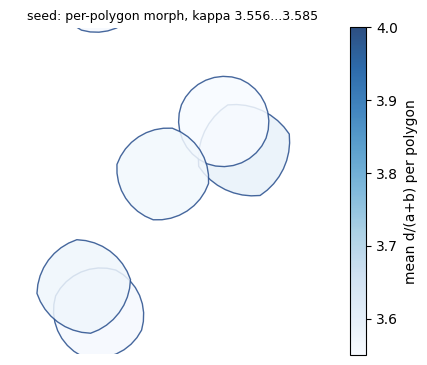

thrown + inflated to phi 0.62000: pair overlap 0.230082 = 37.11% of the polygon area  |turn| 360.000


/tmp/ipykernel_107102/3750496942.py:102: UserWarning: 
*** shape added while constraints were active ***
    Re-run setConstraints() -- the existing constraint blocks do not cover the new polygon.
  packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))


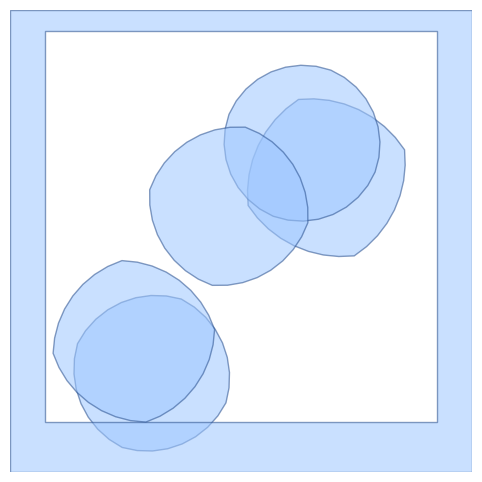

In [2]:
N = 5
n = 32
kappa = 4.0
m0 = 0.20                     # how round the seed is. Small = every vertex genuinely bent
morphSpread = 0.10            # PER-POLYGON spread in morph. Without it there is nothing to trade
seedRounds = 16               # sub-steps for the morph walk. Never move a target in one jump
phi0 = 0.30                   # seed density; the throw may overlap freely, the AREA tier untangles it
phiStart = 0.62               # then inflated to THIS: the run starts genuinely OVERJAMMED
excess = 5e-6                 # OVERJAMMED, and below the 2.4e-05 crush ceiling. Held all the way
flatGoal = 0.999999           # per-object endgame target; 1 is the bound, where the row has no gradient
rampRounds = 10               # moment-ramp rounds per stage
widthNarrowing = 0.25         # end width as a FRACTION of whatever the loaded packing already has
endWidthFloor = 5e-4          # never below this. A point mass makes the two moment rows parallel.
                              # Must sit UNDER the width the load produces (~3e-3) or the schedule
                              # degenerates: at 5e-3 it read "0.00500 -> 0.00500", i.e. no narrowing
handoffRounds = 8             # per-object rounds per stage
wallStiffness = 100.0
coarseness = 1e3
patience = 800
drawEvery = 1                 # snapshot every N ramp rounds. 0 turns the running picture off

print(records.describe(N))
bestKnown = records.bestKnownSide(N)
print(f"densest possible for {N} squares: phi = {records.maximumDensity(N):.4f}")

packing = pp.Model(N = N, n = 4, seed = 42)
packing.generateEquilateralPolygons(phi = phi0, kappa = kappa)
packing.syncTargetAreas()
packing.doubleNumEdges(int(np.log2(n // 4)))
packing.placeRandomly(margin = 0.12)

def count():
    return int(np.diff(packing.packing.startIndices)[0])

def side():
    return float(np.sqrt(N / packing.getPackingFraction()))

def turns(polygon):
    starts = np.asarray(packing.packing.startIndices, dtype = int)
    loop = packing.packing.positions.reshape(-1, 2)[starts[polygon]:starts[polygon + 1]]
    behind = loop - np.roll(loop, 1, axis = 0)
    ahead = np.roll(loop, -1, axis = 0) - loop
    return np.degrees(np.arctan2(np.cross(behind, ahead),
                                 np.einsum("ij,ij->i", behind, ahead)))

def folded():
    """Worst total |turning angle|; 360 exactly for a simple polygon. NOTHING else guards this."""
    return max(float(np.abs(turns(p)).sum()) for p in range(N))

def corners():
    return max(float(np.max(np.abs(np.abs(turns(p)) - 90.0))) for p in range(N))

def drift():
    """max|C| -- projectPositions gives up SILENTLY at maxIter, so it has to be read."""
    return float(packing.constraints.maxResidual(packing.packing))

def perPolygonFlatness():
    """Mean flatness per polygon -- the column that says whether polygons are TRADING."""
    flat = packing.getFlatness()
    return flat.reshape(N, -1).mean(axis = 1)

def jamGap():
    """How far the JAMMED density sits from the best that exists for N squares."""
    return side() / bestKnown - 1.0 if bestKnown else float("nan")

def snapshot(title, colorBy = None, limits = (0.95, 1.0)):
    """Draw the packing as it goes, shaded by how flat each polygon's selected vertices are.

    The colour IS the experiment: the moment family holds only the mean and variance for the whole
    packing, so if it is really sharing the work these should visibly DIFFER -- one polygon dark and
    bent while another is light and flat. A uniformly coloured frame means nothing is being traded."""
    figure, ax = plt.subplots(figsize = (4.6, 4.6))
    if colorBy is None:
        packing.draw(ax = ax)
    else:
        packing.draw(ax = ax, colorBy = colorBy, colorLimits = limits,
                     colorLabel = "mean d/(a+b) per polygon")
    ax.set_title(title, fontsize = 9)
    plt.show()

# PER-POLYGON morph. A scalar makes every polygon the same shape, so the flatness distribution is a
# point mass and two moment rows have nothing to hold: measured, spread 0.000000 with conditioning
# 1.57e-16 even after loading. setShapeTemplate takes one value per polygon precisely so a spread in
# shape is an annealing freedom in its own right, and closing it means driving every entry to 1.
target = np.clip(m0 + morphSpread * packing.rng.standard_normal(N), 0.02, 0.95)
print(f"per-polygon morph: {np.array2string(np.sort(target), precision = 4)}")

# Walk the template round in sub-steps. Rigid (edge + diagonal) so nothing can fold on the way.
packing.setShapeTemplate(morph = 1.0, sides = 4)
packing.setConstraints(area = True, edge = True, diagonal = True)
for step in range(1, seedRounds + 1):
    packing.setShapeTemplate(morph = 1.0 + (target - 1.0) * step / seedRounds, sides = 4)
    packing.constraints.projectPositions(packing.packing)
print(f"seed: n = {count()}   |turn| {folded():.4f}   max|C| {drift():.2e}   pair overlap "
      f"{packing.getPairOverlapArea():.6f}")
print(f"      kappa {np.array2string(packing.getShapeIndices()[:N], precision = 5)}  "
      f"<- spread, which is what the moment family will trade")
snapshot(f"seed: per-polygon morph, kappa {packing.getShapeIndices()[0]:.3f}..."
         f"{packing.getShapeIndices()[:N].max():.3f}",
         colorBy = packing.getShapeIndices()[:N], limits = (3.55, 4.0))

packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
# The container is a new polygon, so the existing constraint blocks do not cover it -- setConstraints
# says so itself. Re-run it before anything reads a force.
packing.setConstraints(area = True, edge = True, diagonal = True)

# START OVERJAMMED. The lattice is laid out loose so no pair begins past half overlap, then every
# polygon is inflated about its own centroid to phiStart. Compressing INTO jamming from a loose grid
# and decompressing DOWN onto it from an overlapped state are different searches; this is the latter.
packing.setPackingFraction(phiStart)
print(f"thrown + inflated to phi {packing.getPackingFraction():.5f}: pair overlap "
      f"{packing.getPairOverlapArea():.6f} = "
      f"{100 * packing.getPairOverlapArea() / float(packing.getAreas()[:N].sum()):.2f}% of the "
      f"polygon area  |turn| {folded():.3f}")
packing.draw()
plt.show()

## 2. Start overjammed, untangle on the AREA tier, then hand to the depth tier

The run **starts overlapped**, not loose. The lattice is laid out at a density where nothing touches,
then every polygon is inflated about its own centroid to `phiStart`. Decompressing onto jamming from
an overlapped state is a different search from compressing into it from a loose one.

That is only safe because the untangling happens on the **overlap-area** tier first. Overlap area is
*maximal* at full stacking, so its gradient always pushes a pair apart — there is no barrier to be
caught behind. The depth law is the opposite: penetration depth peaks near **half** overlap and falls
away to nothing at full stacking, so a fully stacked pair sits in a genuine force-balanced minimum
(measured 4.07e-06 stacked against 1.23e-04 at half). Starting overjammed directly on the depth tier
would mean starting inside that trap. So: `setModelType("sharp")` → relax → `setDepthContact(...)`.

Measured end to end: a random throw inflated to `phi = 0.62` starts at **31.14%** areal overlap, the
area tier takes it to **0.30%** in one pass, and the depth tier then never sees a pair near its
barrier. The untangle runs at `maxUnbalancedForce = 1e-4` with no L-BFGS polish, because the sharp
tier is only **C1** — it kinks where a vertex crosses an edge — so FIRE hits a floor of the *energy*,
not of the minimizer: 800 steps bought no reduction at all at `max|F| = 3.48e-05`. It is an untangler,
not a polish; the depth tier does the converging.

**Where the tier is set to `depth`:** `setDepthContact` *is* the switch — it sets `modelType = "depth"`
itself along with the two stiffnesses, so there is no separate `setModelType("depth")` call. The
notebook prints `packing.modelType` at both switches so the active tier is never in doubt.

**On the starting density:** `phi0` is not the thing to tune. `holdExcessEnergy` compresses to jamming
immediately whatever the seed was, so `phi0` only has to be low enough that the lattice does not
already overlap — past half overlap a pair is trapped in a genuine minimum. What matters is **where it
jams**, printed below against the record.

Measured with the *lattice* seed it jammed at **phi 0.45033, side 3.3321** against the record's
0.6823 / 2.7071 — low, because the 3 x 2 grid for N = 5 leaves a cell empty and the packing jams
around the vacancy. Throwing the polygons in randomly and starting overjammed attacks exactly that:
they are forced into each other's space instead of settling around a hole, and the jamming phi now
varies with the seed, which is what makes restarts worth running. For reference the morph cascade
loaded at 0.5649 and finished at 0.6738.

`holdExcessEnergy(5e-6)` puts the packing at roughly 3% areal overlap and it stays there for the whole
cascade. This is the one genuinely new ingredient: the previous protocols sat at the crush ceiling or
above it, and released before the shapes had done any work.

Watch `pairOverlap` from here on. The contact law is non-monotonic past half overlap — energy peaks
near half and *falls* to nothing at full stacking — so a climbing overlap means the packing has crossed
the barrier and everything after it is meaningless.

contact tier -> 'sharp' (overlap AREA: no barrier, always separates)


FIRE (constrained):  41%|█▋  | 3296/8000 [03:39<05:13, 15.03it/s, maxF=1.00e-04]


area tier untangled: pair overlap 0.004695 = 0.76% of the polygon area   max|F| 9.97e-05   |turn| 360.000


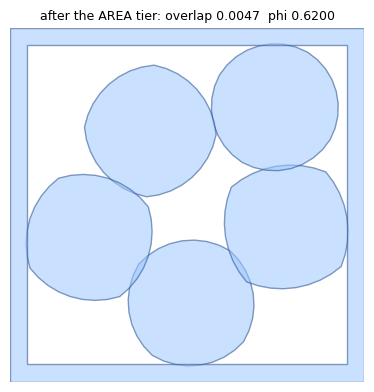

contact tier -> 'depth' (stiffness 1.0, wallStiffness 100.0)


FIRE (constrained):  40%|██   | 808/2000 [00:26<00:38, 31.01it/s, maxF=1.00e-06]
L-BFGS (constrained):   3%| | 120/4000 [00:09<04:51, 13.32it/s, evalsPerStep=1.2
FIRE (constrained):   0%|                             | 0/10000 [00:00<?, ?it/s]


  hold     phi 0.620000  excess 1.4420e-04  (target 5.0000e-06)  pairOverlap 6.308e-04


FIRE (constrained):   0%|                             | 0/10000 [00:00<?, ?it/s]


  hold     phi 0.590476  excess 0.0000e+00  (target 5.0000e-06)  pairOverlap 0.000e+00


...

  hold     phi 0.616230  excess 3.2715e-05  (target 5.0000e-06)  pairOverlap 3.317e-04


FIRE (constrained):   0%|                             | 0/10000 [00:00<?, ?it/s]


  hold     phi 0.613390  excess 5.7799e-06  (target 5.0000e-06)  pairOverlap 1.491e-04


FIRE (constrained):   0%|                             | 0/10000 [00:00<?, ?it/s]


  hold     phi 0.613154  excess 4.8083e-06  (target 5.0000e-06)  pairOverlap 1.356e-04

loaded: excess 4.808e-06  phi 0.61315  side 2.8556  |turn| 360.000  overlap 1.356e-04  max|C| 5.44e-15
        jams at phi 0.61315 / side 2.8556 against the record 2.7071  (+5.49%)
        (thrown at random, so this varies with the seed -- that spread IS the search)


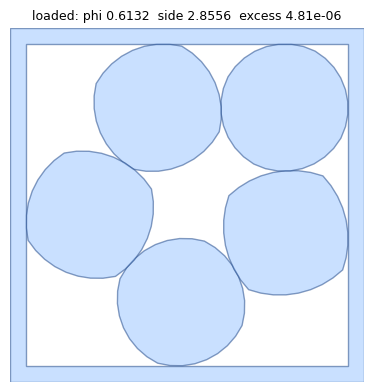

In [3]:
# UNTANGLE ON THE AREA TIER FIRST. The overlap AREA is MAXIMAL at full stacking, so its gradient
# always pushes a pair apart -- there is no barrier to be trapped behind. The depth law is the
# opposite: penetration depth peaks near HALF overlap and falls to nothing at full stacking, so a
# stacked pair sits in a genuine force-balanced minimum (measured 4.07e-06 stacked against 1.23e-04
# at half). Starting overjammed on the depth tier would be starting inside that trap.
packing.setModelType("sharp")
print(f"contact tier -> {packing.modelType!r} (overlap AREA: no barrier, always separates)")
# TOLERANCE 1e-4, and no L-BFGS polish. The sharp area tier is only C1 -- it kinks where a vertex
# crosses an edge -- so FIRE hits a floor of the ENERGY, not of the minimizer: measured, 800 steps
# bought NO reduction at all at max|F| = 3.48e-05. This step is an UNTANGLER, not a polish; the depth
# tier does the converging. Measured on a 31.14% overlapped throw: down to 0.30% in one pass.
packing.minimizeFIRE(maxUnbalancedForce = 1e-4, maxSteps = 8000, patience = patience,
                     progressBar = "text")
print(f"area tier untangled: pair overlap {packing.getPairOverlapArea():.6f} = "
      f"{100 * packing.getPairOverlapArea() / float(packing.getAreas()[:N].sum()):.2f}% of the "
      f"polygon area   max|F| {packing.getMaxUnbalancedForce():.2e}   |turn| {folded():.3f}")
snapshot(f"after the AREA tier: overlap {packing.getPairOverlapArea():.4f}  "
         f"phi {packing.getPackingFraction():.4f}")

# NOW THE DEPTH TIER, with no pair left on the wrong side of its barrier. setDepthContact IS the
# switch -- it sets modelType = "depth" itself, as well as the two stiffnesses -- so there is no
# separate setModelType call. The tier is printed at every switch so it is never in doubt.
packing.setDepthContact(stiffness = 1.0, wallStiffness = wallStiffness)
print(f"contact tier -> {packing.modelType!r} "
      f"(stiffness 1.0, wallStiffness {wallStiffness})")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 4000, coarseness = coarseness,
                          patience = patience, progressBar = "text")
got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True,
                                        innerProgressBar = "text")
print(f"\nloaded: excess {got:.3e}  phi {phi:.5f}  side {side():.4f}  |turn| {folded():.3f}  "
      f"overlap {packing.getPairOverlapArea():.3e}  max|C| {drift():.2e}")
# WHERE IT JAMS is the number to watch, not phi0. The controller compresses to jamming whatever the
# seed density was, so phi0 only has to be low enough that the lattice does not overlap.
print(f"        jams at phi {phi:.5f} / side {side():.4f} against the record "
      f"{bestKnown:.4f}  ({100 * jamGap():+.2f}%)")
print(f"        (thrown at random, so this varies with the seed -- that spread IS the search)")
snapshot(f"loaded: phi {phi:.4f}  side {side():.4f}  excess {got:.2e}")

## 3. The cascade

Per stage: select the every-other set once, swap the per-object diagonals for **2 global moment rows**,
walk the mean flatness toward flat while re-establishing the excess each round, then hand off to the
per-object rows to finish, then remove.

The `spread` and `perPoly` columns are the experiment. If they are zero, nothing is being shared.

In [ ]:
history = []
start = time.time()
while count() > 4:
    stage = count()
    print(f"\n=== stage: n {stage} -> {stage // 2}", flush = True)
    packing.selectFlattening(stride = 2)

    # PER-OBJECT edges and area (from the template, so no kappa gap) + 2 GLOBAL rows on flatness.
    packing.setConstraints(area = True, edge = True, diagonal = [1, 2])
    flat = packing.getFlatness()
    begin = float(flat.mean())
    # CAPTURE the width the loaded packing actually carries, then narrow from there. Guessing it low
    # makes the variance row fight the load: measured, asked 0.042082 against a realized 0.114641,
    # moment residual stuck at 3.6e-02 after 361 passes and reported "targets UNREACHABLE".
    startWidth = max(float(np.std(flat)), endWidthFloor)
    endWidth = max(widthNarrowing * startWidth, endWidthFloor)
    print(f"  selected {flat.size} vertices   flatness mean {begin:.6f}  spread {np.std(flat):.6f}  "
          f"worst {flat.min():.6f}   conditioning {packing.constraintConditioning():.2e}", flush = True)
    print(f"  width schedule {startWidth:.5f} -> {endWidth:.5f} (captured from the load, then "
          f"narrowed)", flush = True)

    for step in range(rampRounds):
        blend = (step + 1) / rampRounds
        target = begin + (0.995 - begin) * blend
        # The WIDTH is scheduled, never captured. Capturing it at a symmetric seed asks for a point
        # mass, and a moment family can only be narrowed -- measured, the retraction then fought the
        # spread the load developed and stuck at residual 8.2e-02.
        packing.setFlatnessTarget(target, width = startWidth + (endWidth - startWidth) * blend)
        packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1200,
                                  coarseness = coarseness, patience = patience,
                                  progressBar = "text")
        got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 10,
                                            maxSteps = 1200, verbose = True,
                                            innerProgressBar = "text")
        flat = packing.getFlatness()
        row = dict(n = stage, phase = "moments", mean = float(flat.mean()),
                   spread = float(np.std(flat)), worst = float(flat.min()),
                   perPoly = float(np.std(perPolygonFlatness())),
                   cond = packing.constraintConditioning(), drift = drift(), folded = folded(),
                   overlap = packing.getPairOverlapArea(), phi = phi, side = side())
        history.append(row)
        print(f"    moments {step + 1:2d}/{rampRounds}  mean {row['mean']:.6f}  "
              f"spread {row['spread']:.6f}  perPoly {row['perPoly']:.6f}  worst {row['worst']:.6f}  "
              f"cond {row['cond']:.1e}  |turn| {row['folded']:7.2f}  lap {row['overlap']:.1e}  "
              f"phi {row['phi']:.5f}  side {row['side']:.4f}", flush = True)
        if drawEvery and (step + 1) % drawEvery == 0:
            snapshot(f"n {stage}  moments {step + 1}/{rampRounds}   mean {row['mean']:.5f}  "
                     f"spread {row['spread']:.5f}   phi {row['phi']:.4f}  side {row['side']:.4f}",
                     colorBy = perPolygonFlatness())

    # HANDOFF. Two rows holding a mean and a variance go parallel as the width goes to zero, so they
    # cannot place the worst vertex; one row per selected vertex has no such limit.
    packing.setConstraints(area = True, edge = True, flatten = True)
    begin = packing.getFlatness().copy()
    for step in range(handoffRounds):
        blend = (step + 1) / handoffRounds
        packing.setFlatTargets((1.0 - blend) * begin + blend * flatGoal)
        packing.constraints.projectPositions(packing.packing)
        packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 1200,
                                  coarseness = coarseness, patience = patience,
                                  progressBar = "text")
        got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", maxRounds = 10,
                                            maxSteps = 1200, verbose = True,
                                            innerProgressBar = "text")
    flat = packing.getFlatness()
    history.append(dict(n = stage, phase = "perObject", mean = float(flat.mean()),
                        spread = float(np.std(flat)), worst = float(flat.min()),
                        perPoly = float(np.std(perPolygonFlatness())), cond = float("nan"),
                        drift = drift(), folded = folded(),
                        overlap = packing.getPairOverlapArea(), phi = phi, side = side()))
    print(f"    per-object -> worst {flat.min():.8f}   |turn| {folded():.3f}   "
          f"max|C| {drift():.2e}", flush = True)
    snapshot(f"n {stage}  after per-object handoff   worst {flat.min():.6f}   side {side():.4f}",
             colorBy = perPolygonFlatness())

    areaBefore = packing.getAreas()[:N].copy()
    packing.setConstraints(area = True, edge = True)     # diagonal/flatten OFF across the removal
    packing.halveNumEdges()
    print(f"  removed -> n = {count()}   dArea "
          f"{np.max(np.abs(packing.getAreas()[:N] / areaBefore - 1)):.2e}   "
          f"|turn| {folded():.4f}", flush = True)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-9, maxSteps = 2000,
                              coarseness = coarseness, patience = patience,
                              progressBar = "text")
    got, phi = packing.holdExcessEnergy(excess, minimizer = "fireLbfgs", verbose = True,
                                        innerProgressBar = "text")
    snapshot(f"removed -> n = {count()}   phi {phi:.4f}  side {side():.4f}  "
             f"|turn| {folded():.2f}")

print(f"\ncascade took {time.time() - start:.1f} s")
packing.draw()
plt.show()


=== stage: n 32 -> 16
  selected 80 vertices   flatness mean 0.996603  spread 0.000725  worst 0.995485   conditioning 2.89e-04
  width schedule 0.00072 -> 0.00050 (captured from the load, then narrowed)


FIRE (constrained):   0%|                               | 0/600 [00:00<?, ?it/s]
L-BFGS (constrained):   0%| | 5/1200 [00:00<01:04, 18.57it/s, evalsPerStep=3.4, 
FIRE (constrained):   0%|                               | 0/600 [00:00<?, ?it/s]


  hold     phi 0.613154  excess 1.4921e-08  (target 5.0000e-06)  pairOverlap 1.416e-05


/home/rdennis/Documents/Code/pyPolygon/minimize.py:383: UserWarning: 
*** moment retraction did not converge ***
    residual 1.136e-01 after 473 passes (tolerance 1.0e-12); conditioning 2.64e-02 across 2 rows.
    The per-object constraints ARE still satisfied, so the geometry is valid -- it is the moment TARGETS that were not reached.
    diagonal: asked 0.000705, got 0.045855 (4.5e-02 off)
    Judge it on THOSE, not on the residual: if the widths agree to far better than a step of your ramp, this is cosmetic.
    A residual that barely moves across passes means the targets are UNREACHABLE, not that the budget is short -- no iteration count fixes that. Repeats from this constraint set are suppressed.
  _retract(constraints, packing, shakeTol, shakeMaxIter)
FIRE (constrained): 100%|██████| 600/600 [06:50<00:00,  1.46it/s, maxF=8.08e-04]
L-BFGS (constrained):  10%| | 125/1200 [34:14<4:37:05, 15.47s/it, evalsPerStep=2

## 4. Release

At n = 4 the constraint set forces the square on its own — an equilateral quadrilateral at kappa 4 is
a square and nothing else. `setRegularTargets()` derives `P = 4 sqrt(A)` from each polygon's own area
target so kappa lands exactly on its floor rather than banking whatever the removals cost.

Then, and only then, decompress: walk the excess down by decades to the noise floor.

In [ ]:
packing.setRegularTargets()
packing.setConstraints(area = True, edge = True)
packing.minimizeFIRE(maxUnbalancedForce = 1e-7, maxSteps = 20000, patience = patience,
                     progressBar = "text")
for level in (1e-6, 1e-7, 1e-8):
    got, phi = packing.holdExcessEnergy(level, minimizer = "fireLbfgs", maxRounds = 30,
                                        verbose = True, innerProgressBar = "text")
    print(f"  released to excess {got:.2e}   phi {phi:.6f}   side {side():.6f}   "
          f"|turn| {folded():.4f}")
    snapshot(f"released to excess {got:.1e}   phi {phi:.5f}  side {side():.5f}")
packing.minimizeFireLBFGS(maxUnbalancedForce = 1e-10, maxSteps = 8000, coarseness = coarseness,
                          patience = patience, progressBar = "text")
packing.checkDensityFeasible()

result = side()
print(f"\nOVERJAMMED ARM   phi {packing.getPackingFraction():.6f}   side {result:.6f}   "
      f"worst |corner - 90| {corners():.6f} deg")
print(f"                 kappa {np.array2string(packing.getShapeIndices()[:N], precision = 6)}")
print(f"                 max|C| {drift():.2e}   |turn| {folded():.4f}")
if bestKnown is not None:
    print(f"                 record {bestKnown:.6f}   ({100 * (result / bestKnown - 1):+.3f}% off)")
print(f"\n  reference: morph cascade 2.724149 (+0.630%), rigid control 2.727423 (+0.751%)")
packing.draw()
plt.show()

In [ ]:
figure, axes = plt.subplots(1, 4, figsize = (19, 4))
x = np.arange(len(history))
edges = [i for i in range(1, len(history)) if history[i]["n"] != history[i - 1]["n"]]
for ax in axes:
    ax.set_xlabel("round (dotted = a removal)")
    for e in edges:
        ax.axvline(e - 0.5, color = "0.7", linestyle = ":")

axes[0].plot(x, [h["mean"] for h in history], marker = "o", label = "mean flatness")
axes[0].plot(x, [h["worst"] for h in history], marker = ".", label = "worst")
axes[0].axhline(1.0, linestyle = "--", color = "0.5", label = "flat (removable)")
axes[0].set_ylabel("d/(a+b)"); axes[0].legend()

# THE EXPERIMENT: if these are zero, nothing is being shared globally.
axes[1].semilogy(x, [max(h["spread"], 1e-16) for h in history], marker = "o", label = "vertex spread")
axes[1].semilogy(x, [max(h["perPoly"], 1e-16) for h in history], marker = ".",
                 label = "per-POLYGON spread")
axes[1].set_ylabel("is anything being TRADED?"); axes[1].legend()

axes[2].semilogy(x, [max(h["drift"], 1e-16) for h in history], marker = "o", label = "max|C|")
axes[2].semilogy(x, [max(h["overlap"], 1e-16) for h in history], marker = ".", label = "pair overlap")
axes[2].set_ylabel("health"); axes[2].legend()

axes[3].plot(x, [h["side"] for h in history], marker = "o", label = "side")
if bestKnown is not None:
    axes[3].axhline(bestKnown, linestyle = "--", color = "#c0392b", label = "record")
axes[3].set_ylabel("side (lower is better)"); axes[3].legend(); axes[3].invert_yaxis()
plt.tight_layout(); plt.show()